В данной работе проводится обработка результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель с несколькими компонентами кинематического упрочнения - **CHAB**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [1]:
model_name = "CHAB"

nu_path = r"nu.txt"
with open(nu_path, "r") as f:
        nu = float(f.read().strip())
nu

0.299999999999

In [2]:
a_path = r"a.txt"
with open(a_path, "r") as f:
        a = float(f.read().strip())

c_path = r"c.txt"
with open(c_path, "r") as f:
        c = float(f.read().strip())

n_turns_path = r"n_turns.txt"
with open(n_turns_path, "r") as f:
        n_turns = float(f.read().strip())

a, c, n_turns

(0.0157, 0.0025, 1.65)

In [3]:
from core.reader import read_ansys_csv

path_compressible = r"chab.csv"
path_incompressible = r"chab_incompressible.csv"

numerical_experiment_chab = read_ansys_csv(path_compressible)
numerical_experiment_chab_inc = read_ansys_csv(path_incompressible)

### 1. Первичный обзор данных
Проверим структуру загруженного DataFrame. Данные содержат временные метки, компоненты тензоров деформаций (упругих `EPEL`, пластических `EPPL`, полных `EPTO`), напряжений (`S`), а также интенсивность деформаций и параметр Одквиста.

In [4]:
numerical_experiment_chab.sample(3, random_state=42)

,Time,EPEL_TT,EPPL_TT,EPTO_TT,EPEL_ZZ,EPPL_ZZ,EPTO_ZZ,EPEL_TZ,EPPL_TZ,EPTO_TZ,EPEL_RR,EPPL_RR,EPTO_RR,S_TT,S_ZZ,S_TZ,S_EQV,S_RR,EPPL_EQV,Unnamed: 19
3207,213.7178,0.001745,0.001579,0.003324,0.000351,0.005604,0.005955,-0.001328,-0.002674,-0.004002,-0.000898,-0.007183,-0.008081,416.7897,197.01830,-104.70050,404.1055,0.0,0.007705,NaN
5890,392.5178,0.002046,0.007009,0.009055,-0.000236,0.002751,0.002515,0.001263,-0.001734,-0.000471,-0.000776,-0.009759,-0.010535,445.0322,85.19429,99.61383,444.0341,0.0,0.010114,NaN
8814,587.4178,0.001575,0.010192,0.011767,0.001577,0.004258,0.005836,0.000680,0.003401,0.004081,-0.001351,-0.014450,-0.015801,461.4001,461.79020,53.61945,470.8453,0.0,0.014980,NaN


In [5]:
numerical_experiment_chab_inc.sample(3, random_state=42)

,Time,EPEL_TT,EPPL_TT,EPTO_TT,EPEL_ZZ,EPPL_ZZ,EPTO_ZZ,EPEL_TZ,EPPL_TZ,EPTO_TZ,EPEL_RR,EPPL_RR,EPTO_RR,S_TT,S_ZZ,S_TZ,S_EQV,S_RR,EPPL_EQV,Unnamed: 19
3207,213.7178,0.001524,0.001799,0.003324,0.000006,0.005949,0.005955,-0.001564,-0.002438,-0.004002,-0.001531,-0.007748,-0.009279,417.5345,210.04020,-106.84270,406.2007,0.0,0.008231,NaN
5890,392.5178,0.001990,0.007065,0.009055,-0.000651,0.003166,0.002515,0.001329,-0.001800,-0.000471,-0.001339,-0.010231,-0.011570,454.8702,93.98034,90.82695,444.6785,0.0,0.010527,NaN
8814,587.4178,0.001175,0.010592,0.011767,0.001115,0.004721,0.005836,0.000776,0.003305,0.004081,-0.002290,-0.015312,-0.017603,473.6760,465.42190,53.05719,478.5107,0.0,0.015799,NaN


### 2. Графики полных деформаций
Построим графики изменения компонент тензора полных деформаций от времени.
* `EPTO_ZZ` — осевая деформация ($\varepsilon_z$).
* `EPTO_TT` — окружная деформация ($\varepsilon_\theta$).
* `EPTO_TZ` — деформация сдвига ($\varepsilon_{\theta z}$).

На первом этапе (растяжение) должна меняться только $\varepsilon_z$. На втором этапе (винт) должны меняться все компоненты.

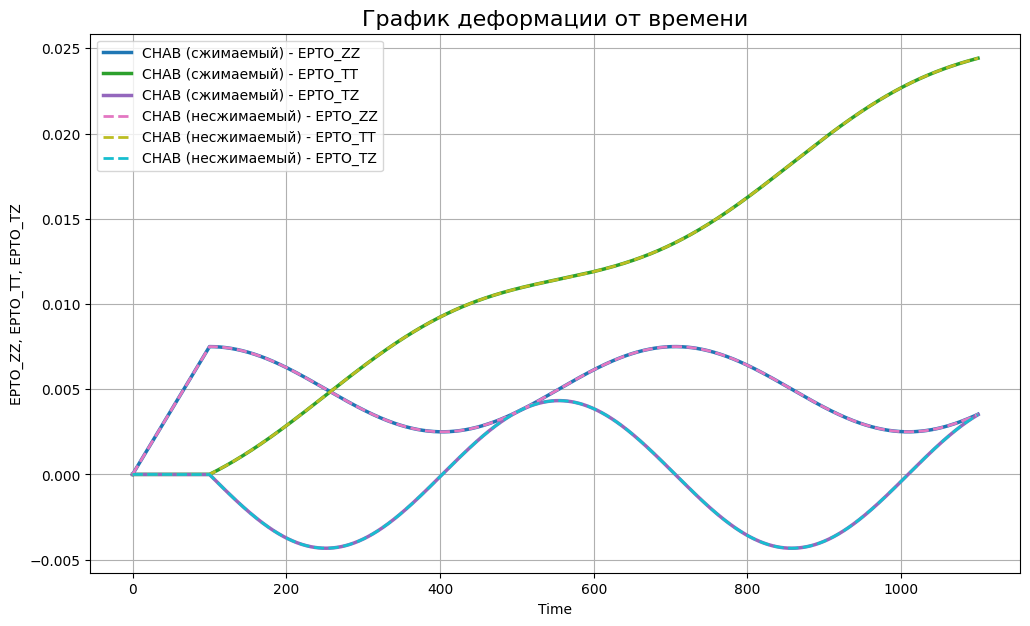

In [6]:
from core.visualizer import plot_xy

plot_xy(
    [
        (f"{model_name} (сжимаемый)", numerical_experiment_chab),
        (f"{model_name} (несжимаемый)", numerical_experiment_chab_inc),
    ],
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    "График деформации от времени",
    figsize=(12, 7),
)


### 3. Расчет вектора деформаций Ильюшина
Для анализа сложных процессов деформирования перейдем от тензорного представления к векторному в пятимерном евклидовом пространстве А.А. Ильюшина $E^5$.

Компоненты вектора деформаций $\bar{\ni}$ линейно выражаются через компоненты тензора деформаций. Для случая тонкостенного трубчатого образца (где $\varepsilon_{11} = \varepsilon_z$ — осевая, $\varepsilon_{22} = \varepsilon_\theta$ — окружная, $\varepsilon_{12} = \varepsilon_{\theta z}$ — сдвиговая) формулы принимают вид:

$$ \ni_1 = \varepsilon_z - \varepsilon_{mean}$$
$$ \ni_2 = \frac{1}{\sqrt{3}} ((\varepsilon_z - \varepsilon_{mean}) + 2(\varepsilon_\theta - \varepsilon_{mean})) $$
$$ \ni_3 = \frac{2}{\sqrt{3}} \varepsilon_{\theta z} $$

Это позволяет нам анализировать траекторию деформирования как кривую в векторном пространстве, вычислять ее кривизну и угол сближения.

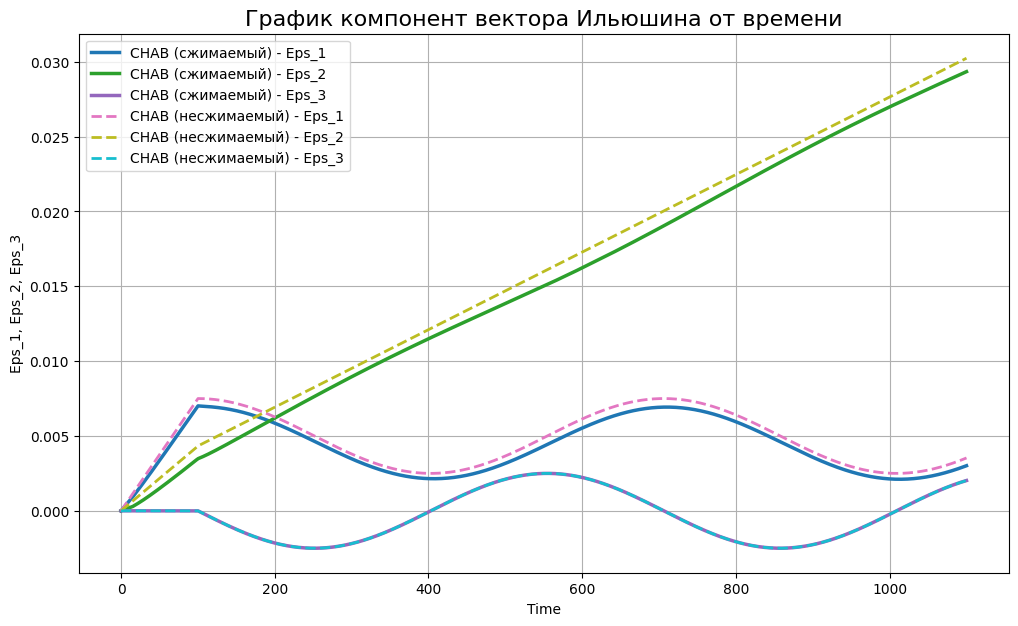

In [8]:
from core.calculations import calculate_ilushin_strain_vector
from core.visualizer import plot_xy

il_chab = calculate_ilushin_strain_vector(
    numerical_experiment_chab,
    compressible=True,
)

il_chab_inc = calculate_ilushin_strain_vector(
    numerical_experiment_chab_inc,
    compressible=False,
)

plot_xy(
    [
        (f"{model_name} (сжимаемый)", il_chab),
        (f"{model_name} (несжимаемый)", il_chab_inc),
    ],
    "Time",
    ["Eps_1", "Eps_2", "Eps_3"],
    "График компонент вектора Ильюшина от времени",
    figsize=(12, 7),
)

### 4. Разделение этапов деформирования
Процесс нагружения состоит из двух этапов:
1.  **Одноосное растяжение** (прямолинейный участок траектории).
2.  **Сложное нагружение** (винтовая траектория).

Нам необходимо выделить данные, относящиеся только ко второму этапу, так как именно на нем исследуются эффекты сложного деформирования (кручение, кривизна траектории). Момент окончания первого этапа считываем из файла конфигурации `steps_n1.txt`.

In [9]:
step_n1_path = r"steps_n1.txt"
with open(step_n1_path, "r") as f:
        split_time = float(f.read().strip())
split_time

100.0

In [10]:
df_stage2 = il_chab[
    il_chab["Time"] > split_time
].copy()
df_stage2.reset_index(drop=True, inplace=True)
df_stage2["Time_Local"] = df_stage2["Time"] - split_time

df_stage2_inc = il_chab_inc[
    il_chab_inc["Time"] > split_time
].copy()
df_stage2_inc.reset_index(drop=True, inplace=True)
df_stage2_inc["Time_Local"] = df_stage2_inc["Time"] - split_time

### Длина дуги в пространстве деформаций Ильюшина

Вектор деформаций Ильюшина в каждой точке по времени задаётся тремя компонентами $\boldsymbol{\varepsilon} = (\varepsilon_1, \varepsilon_2, \varepsilon_3)^\top$. Точки нумеруются в порядке возрастания выбранного времени.

Обозначим упорядоченные точки $\boldsymbol{\varepsilon}^{(0)}, \boldsymbol{\varepsilon}^{(1)}, \ldots, \boldsymbol{\varepsilon}^{(N)}$. Приращение между соседними точками:

$$
\Delta \boldsymbol{\varepsilon}^{(k)} = \boldsymbol{\varepsilon}^{(k)} - \boldsymbol{\varepsilon}^{(k-1)}, \quad k = 1,\ldots,N.
$$

Евклидова длина шага:

$$
\Delta s_k = \left\| \Delta \boldsymbol{\varepsilon}^{(k)} \right\| =
\sqrt{(\Delta \varepsilon_1^{(k)})^2 + (\Delta \varepsilon_2^{(k)})^2 + (\Delta \varepsilon_3^{(k)})^2}.
$$

**Накопленная длина дуги** от начала выбранного интервала:

$$
s^{(0)} = 0, \qquad
s^{(m)} = \sum_{k=1}^{m} \Delta s_k, \quad m = 1,\ldots,N.
$$

Таким образом, $s$ в каждой строке — длина ломаной в трёхмерном пространстве $(\varepsilon_1, \varepsilon_2, \varepsilon_3)$, накопленная по шагам времени.

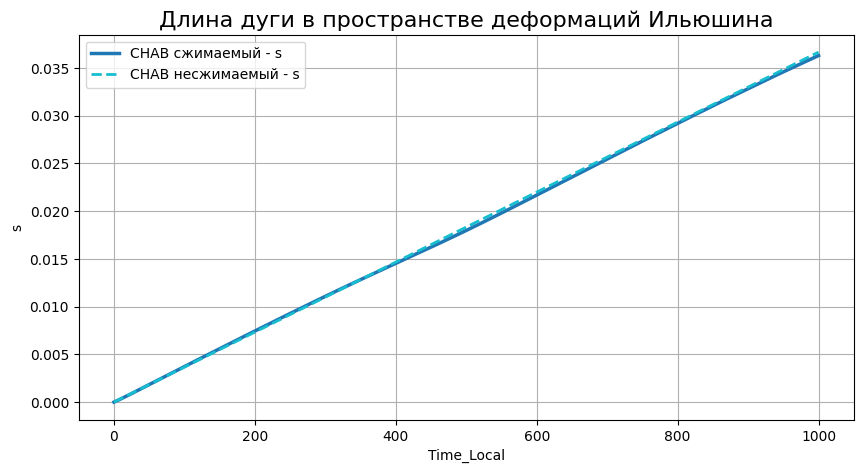

In [11]:
from core.calculations import ilushin_strain_path_length
from core.visualizer import plot_xy

s_comp = ilushin_strain_path_length(
  df_stage2,
  "Time_Local",
  use_existing_ilushin_strains=True,
)
s_inc = ilushin_strain_path_length(
  df_stage2_inc,
  "Time_Local",
  use_existing_ilushin_strains=True,
)

df_stage2 = df_stage2.merge(s_comp, on="Time_Local", how="left")
df_stage2_inc = df_stage2_inc.merge(s_inc, on="Time_Local", how="left")

plot_xy(
  [
      (f"{model_name} сжимаемый", s_comp),
      (f"{model_name} несжимаемый", s_inc),
  ],
  "Time_Local",
  ["s"],
  "Длина дуги в пространстве деформаций Ильюшина",
  figsize=(10, 5),
)


### 5. Аналитическое решение

Для сравнения используется аналитическое решение для **идеально несжимаемого материала** ($\nu=0.5$). В этом случае траектория в пространстве деформаций является идеальной винтовой линией.

Параметризация выполняется по **длине дуги** $s$.
Связь угла поворота $\alpha$ и пути $s$ задается через пространственную частоту $\lambda$:
$$ \alpha(s) = \lambda \cdot s, \quad \text{где } \lambda = \frac{2\pi}{\sqrt{a^2 + (2\pi c)^2}} $$

Производные вычисляются по параметру $s$: $\frac{d\bar{\ni}}{ds}, \frac{d^2\bar{\ni}}{ds^2}, \frac{d^3\bar{\ni}}{ds^3}$.

---

**1. Уравнения траектории (зависимость от $\alpha$):**
В предположении несжимаемости ($\varepsilon_{mean}=0$) компоненты деформаций описываются кинематическими соотношениями:
$$ \varepsilon_z(\alpha) = c \cdot (\cos\alpha - 1) $$
$$ \varepsilon_\theta(\alpha) = \frac{\sqrt{3} a \alpha}{4\pi} - \frac{1}{2} c \cdot (\cos\alpha - 1) $$
$$ \varepsilon_{\theta z}(\alpha) = -\frac{\sqrt{3}}{2} c \cdot \sin\alpha $$

**2. Вектор Ильюшина (переход к базису $\ni_i$):**
Подставляя уравнения траектории в формулы преобразования к векторному пространству для несжимаемого материала:

$$ \ni_1(\alpha) = \varepsilon_z = c(\cos\alpha - 1) $$
$$ \ni_2(\alpha) = \frac{1}{\sqrt{3}}(\varepsilon_z + 2\varepsilon_\theta) = \frac{a \alpha}{2\pi} $$
$$ \ni_3(\alpha) = \frac{2}{\sqrt{3}}\varepsilon_{\theta z} = -c \sin\alpha $$

**3. Производные по длине дуги $s$:**
Используя цепное правило дифференцирования $\frac{d}{ds} = \frac{d}{d\alpha} \frac{d\alpha}{ds} = \lambda \frac{d}{d\alpha}$, получаем:

*   **Первая производная (Скорость, $\mathbf{v}$):**
    $$ \ni_1' = -c \lambda \sin(\lambda s) $$
    $$ \ni_2' = \frac{a \lambda}{2\pi} = \text{const} $$
    $$ \ni_3' = -c \lambda \cos(\lambda s) $$

*   **Вторая производная (Кривизна/Ускорение, $\mathbf{a}$):**
    $$ \ni_1'' = -c \lambda^2 \cos(\lambda s) $$
    $$ \ni_2'' = 0 $$
    $$ \ni_3'' = c \lambda^2 \sin(\lambda s) $$

*   **Третья производная (Рывок, $\mathbf{j}$):**
    $$ \ni_1''' = c \lambda^3 \sin(\lambda s) $$
    $$ \ni_2''' = 0 $$
    $$ \ni_3''' = c \lambda^3 \cos(\lambda s) $$

Эти формулы используются для аналитического расчета кривизны $\varkappa$ и кручения $\tau$. Из равенства нулю второй и третьей производной для компоненты $\ni_2$ следует, что для идеальной траектории геометрические характеристики должны быть **константами**.

In [13]:
from core.derivatives.analytical import AnalyticalDerivatives

analytical = AnalyticalDerivatives(c=c, a=a) 

s_vals = s_comp["s"].to_numpy()

start_row = numerical_experiment_chab[numerical_experiment_chab["Time"] <= split_time].iloc[-1]
eps_z_start = start_row["EPTO_ZZ"]
eps_theta_start = start_row["EPTO_TT"]

E1, E2, E3 = analytical.get_values(s_vals, eps_z_start, eps_theta_start)
df_stage2["Eps_1_analytic"] = E1
df_stage2["Eps_2_analytic"] = E2
df_stage2["Eps_3_analytic"] = E3

dE, d2E, d3E = analytical.get_all_derivatives(s_vals)

df_stage2["dEps_1_analytic"] = dE[0]
df_stage2["dEps_2_analytic"] = dE[1]
df_stage2["dEps_3_analytic"] = dE[2]

df_stage2["d2Eps_1_analytic"] = d2E[0]
df_stage2["d2Eps_2_analytic"] = d2E[1]
df_stage2["d2Eps_3_analytic"] = d2E[2]

df_stage2["d3Eps_1_analytic"] = d3E[0]
df_stage2["d3Eps_2_analytic"] = d3E[1]
df_stage2["d3Eps_3_analytic"] = d3E[2]

In [14]:
from core.derivatives.analytical import AnalyticalDerivatives

analytical = AnalyticalDerivatives(c=c, a=a) 

s_vals = s_inc["s"].to_numpy()

start_row = numerical_experiment_chab_inc[numerical_experiment_chab_inc["Time"] <= split_time].iloc[-1]
eps_z_start = start_row["EPTO_ZZ"]
eps_theta_start = start_row["EPTO_TT"]

E1, E2, E3 = analytical.get_values(s_vals, eps_z_start, eps_theta_start)
df_stage2_inc["Eps_1_analytic"] = E1
df_stage2_inc["Eps_2_analytic"] = E2
df_stage2_inc["Eps_3_analytic"] = E3

dE, d2E, d3E = analytical.get_all_derivatives(s_vals)

df_stage2_inc["dEps_1_analytic"] = dE[0]
df_stage2_inc["dEps_2_analytic"] = dE[1]
df_stage2_inc["dEps_3_analytic"] = dE[2]

df_stage2_inc["d2Eps_1_analytic"] = d2E[0]
df_stage2_inc["d2Eps_2_analytic"] = d2E[1]
df_stage2_inc["d2Eps_3_analytic"] = d2E[2]

df_stage2_inc["d3Eps_1_analytic"] = d3E[0]
df_stage2_inc["d3Eps_2_analytic"] = d3E[1]
df_stage2_inc["d3Eps_3_analytic"] = d3E[2]

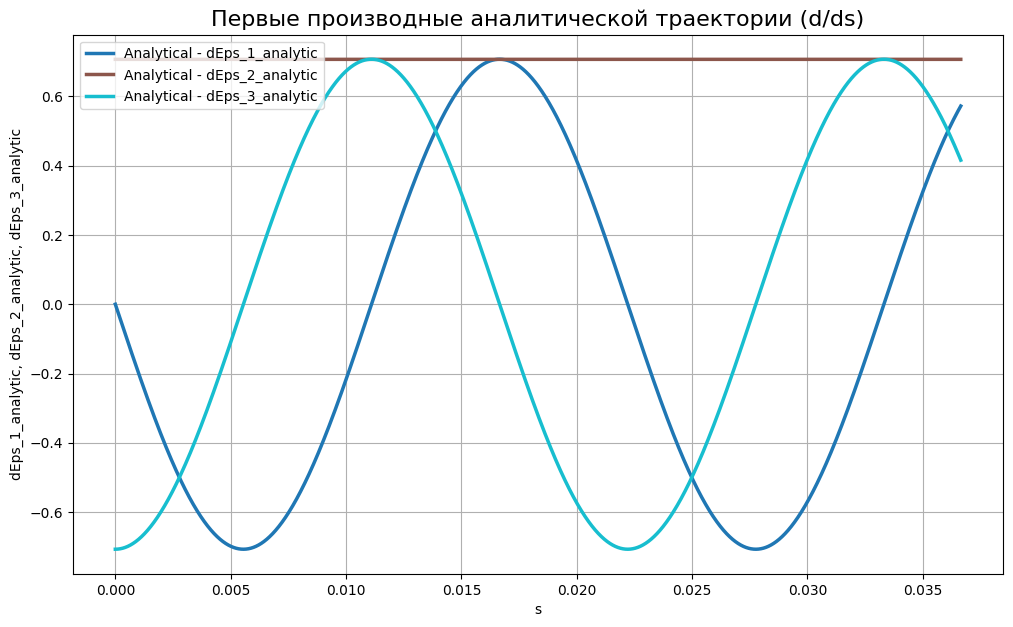

In [15]:
plot_xy(
    [("Analytical", df_stage2_inc)],
    "s",
    ["dEps_1_analytic", "dEps_2_analytic", "dEps_3_analytic"],
    "Первые производные аналитической траектории (d/ds)",
    figsize=(12, 7)
)

На основе проведенного анализа (Grid Search) были определены оптимальные значения гиперпараметров сплайна ($s_{opt}, k_{opt}$), обеспечивающие наилучший баланс между точностью аппроксимации и гладкостью высших производных.

In [16]:
best_s, best_k = 4.7508101621027935e-12, 4

Предполагая, что погрешности решателя ANSYS одинаковы для всех компонент деформаций, мы применяем найденные параметры для дифференцирования **всех компонент** вектора Ильюшина ($\ni_1, \ni_2, \ni_3$).

В результате для каждой компоненты вычисляются и сохраняются в DataFrame:
1.  **Скорость** (${\ni}'$) — префикс `d`
2.  **Ускорение** (${\ni}''$) — префикс `d2`
3.  **Рывок** (${\ni}'''$) — префикс `d3` (необходим для расчета кручения $\tau$)

In [17]:
from core.derivatives.spline import compute_spline_derivatives

components = ["Eps_1", "Eps_2", "Eps_3"]

for df in (df_stage2, df_stage2_inc):
    for col in components:
        d1, d2, d3 = compute_spline_derivatives(
            df,
            col_name=col,
            time_col="s",
            s=best_s,
            k=best_k,
        )
        df[f"d{col}_spline"] = d1
        df[f"d2{col}_spline"] = d2
        df[f"d3{col}_spline"] = d3

Ниже представлены графики изменения компонент вектора деформаций $\ni_1$ и $\ni_3$, а также их вычисленных производных: скорости (${\ni}'$), ускорения (${\ni}''$) и рывка (${\ni}'''$).

*   **Компонента $\ni_1$** (соответствует осевой деформации $\varepsilon_z$) — отражает процесс растяжения/сжатия в ходе движения по винтовой траектории.
*   **Компонента $\ni_3$** (соответствует сдвигу $\varepsilon_{\theta z}$) — отражает процесс чистого кручения.

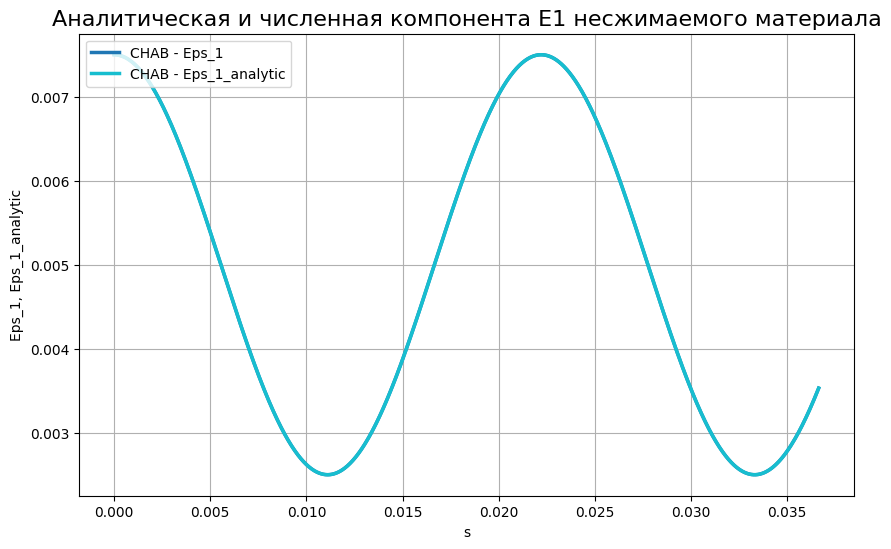

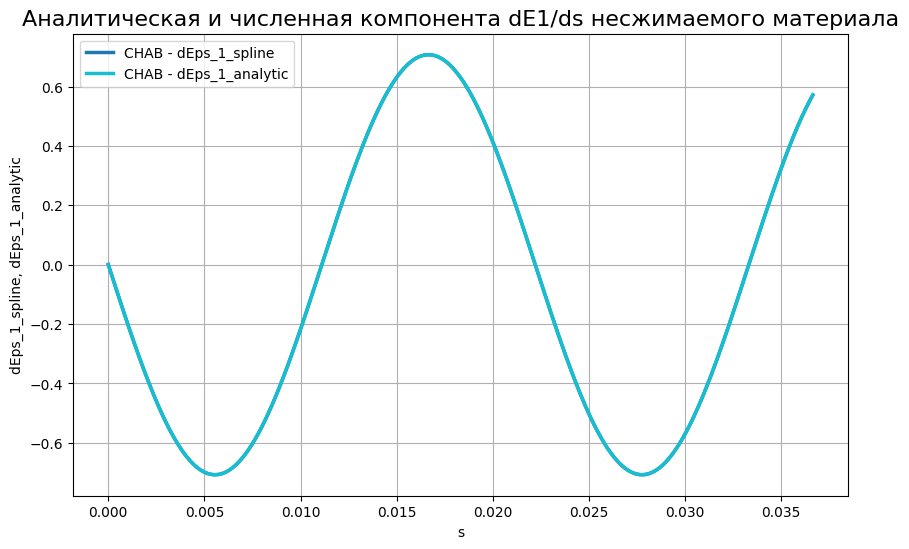

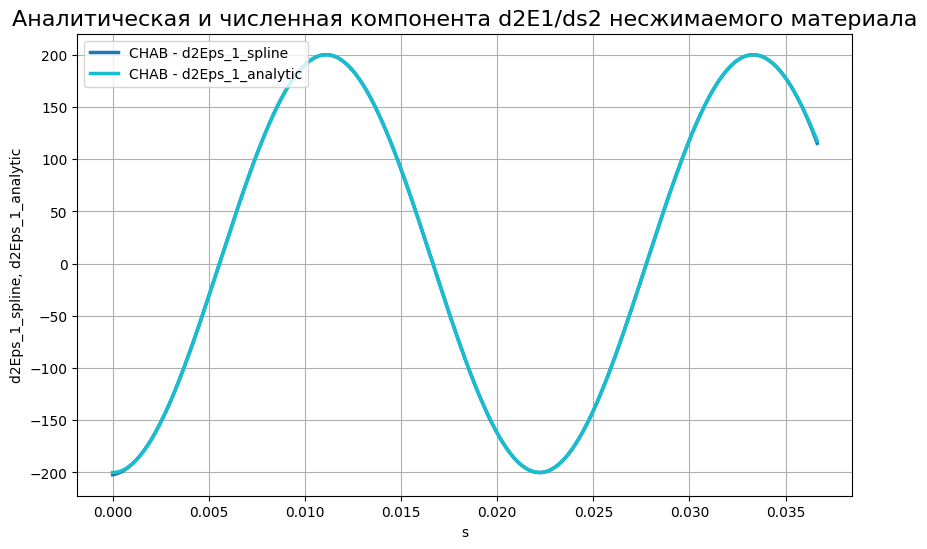

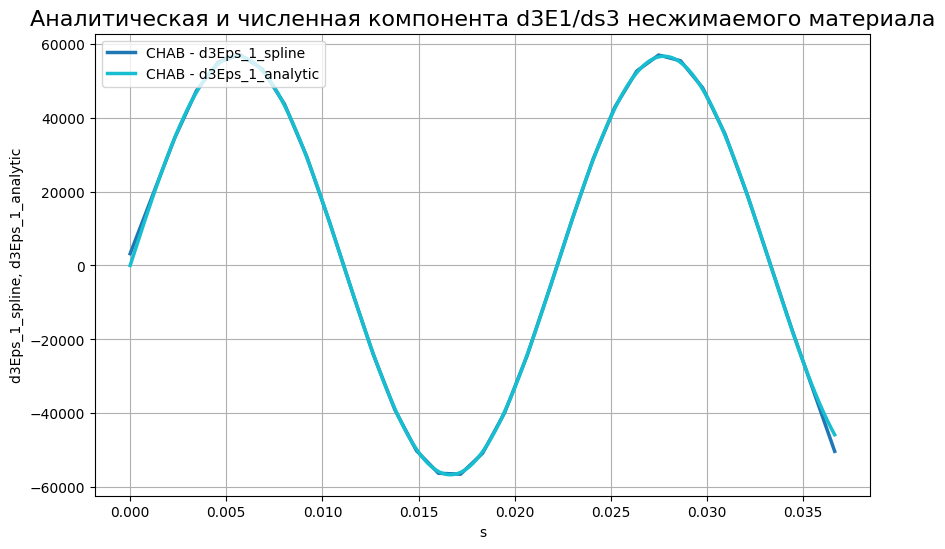

In [18]:
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["Eps_1", "Eps_1_analytic"],
    title="Аналитическая и численная компонента E1 несжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["dEps_1_spline", "dEps_1_analytic"],
    title="Аналитическая и численная компонента dE1/ds несжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["d2Eps_1_spline", "d2Eps_1_analytic"],
    title="Аналитическая и численная компонента d2E1/ds2 несжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["d3Eps_1_spline", "d3Eps_1_analytic"],
    title="Аналитическая и численная компонента d3E1/ds3 несжимаемого материала",
    figsize=(10, 6)
)

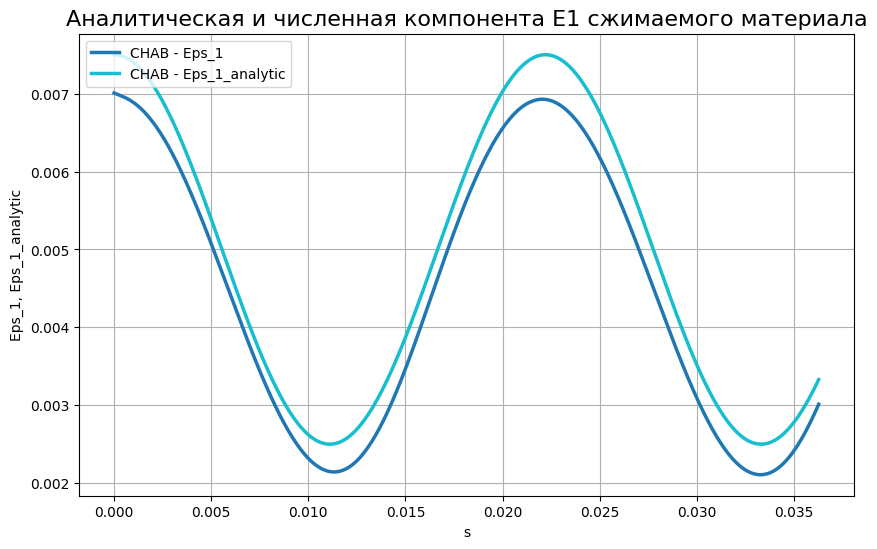

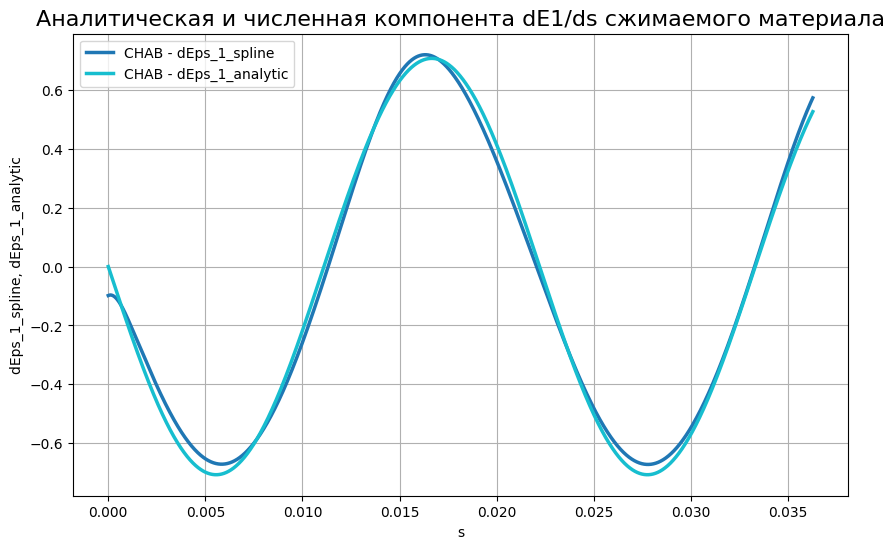

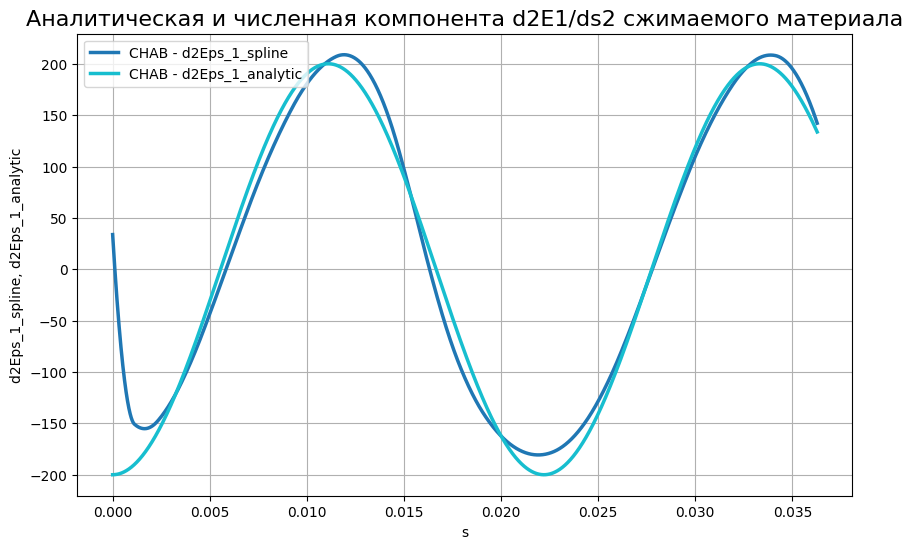

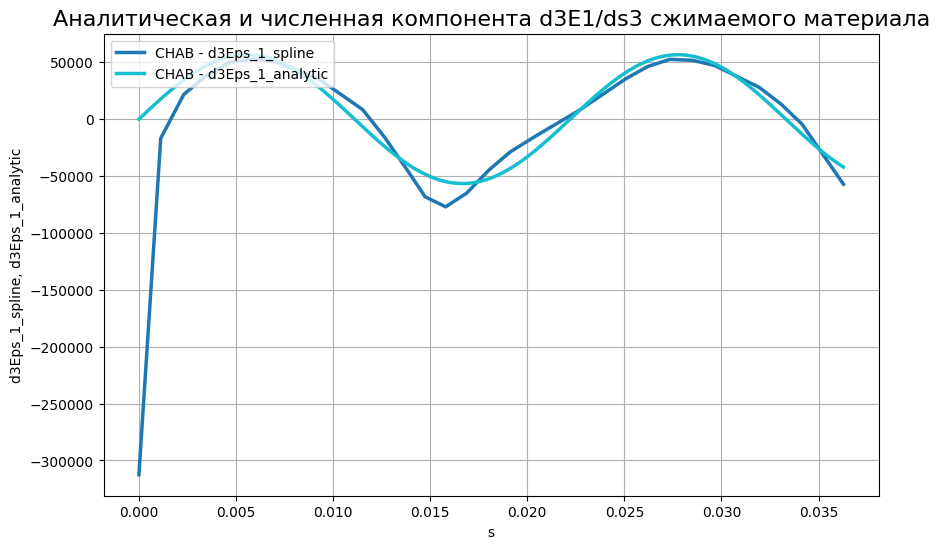

In [19]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["Eps_1", "Eps_1_analytic"],
    title="Аналитическая и численная компонента E1 сжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["dEps_1_spline", "dEps_1_analytic"],
    title="Аналитическая и численная компонента dE1/ds сжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d2Eps_1_spline", "d2Eps_1_analytic"],
    title="Аналитическая и численная компонента d2E1/ds2 сжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d3Eps_1_spline", "d3Eps_1_analytic"],
    title="Аналитическая и численная компонента d3E1/ds3 сжимаемого материала",
    figsize=(10, 6)
)

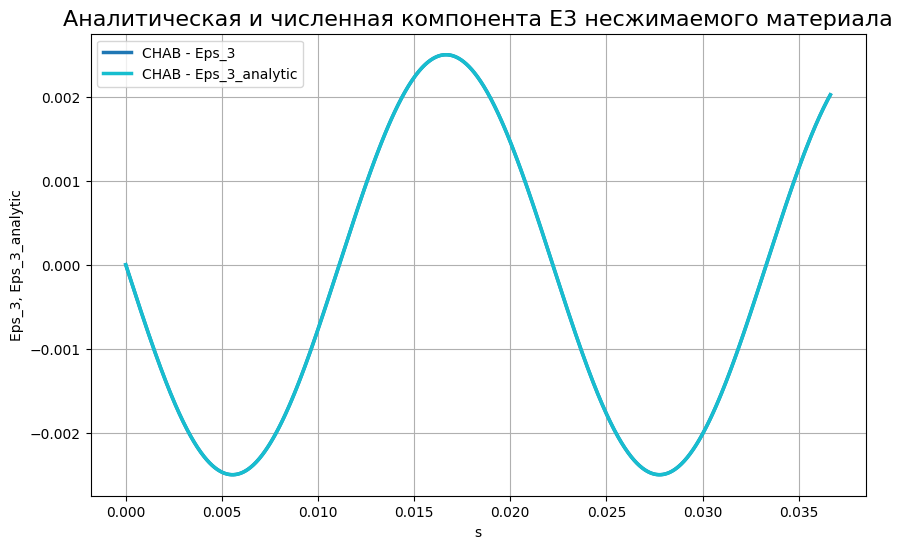

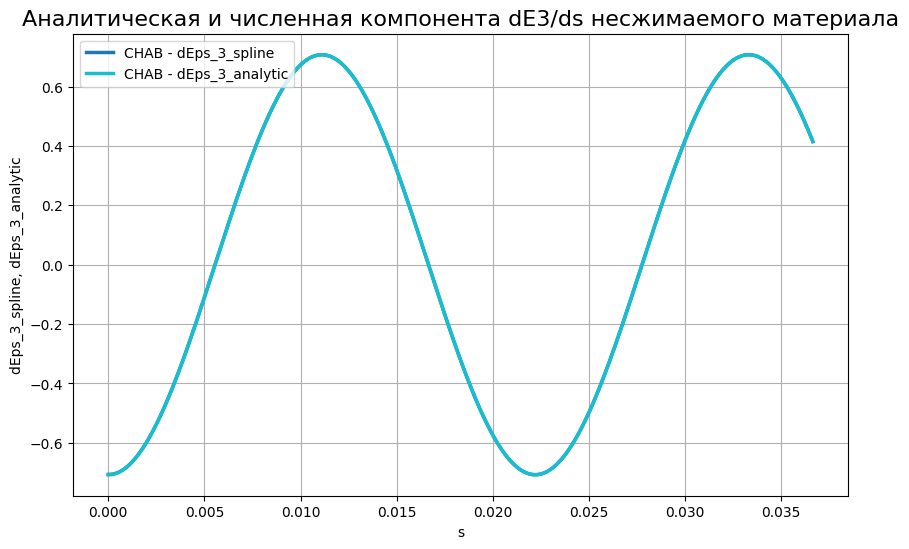

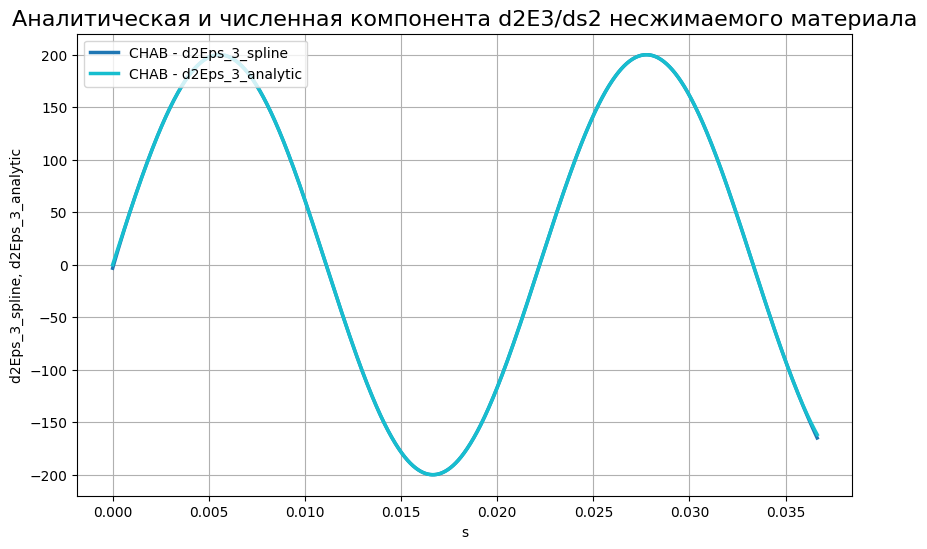

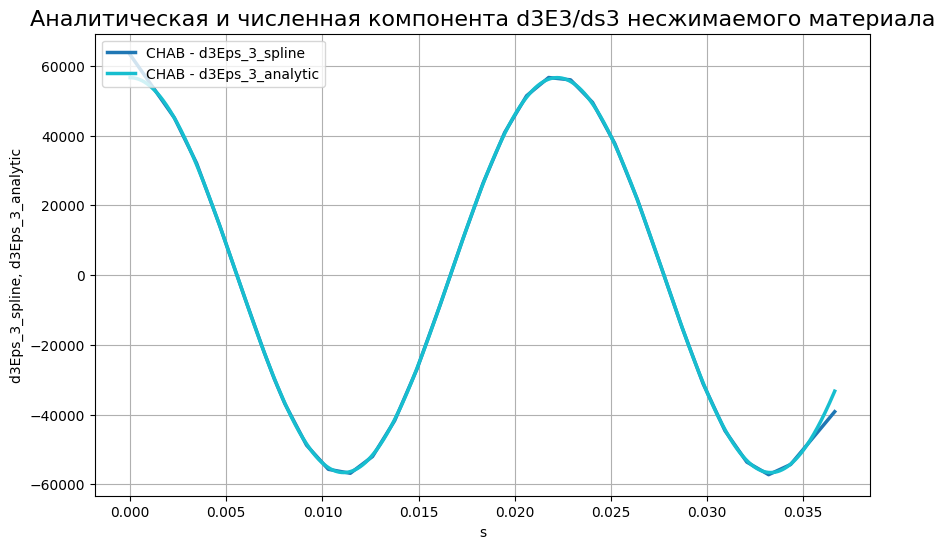

In [20]:
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["Eps_3",
            "Eps_3_analytic",
        ],
    title="Аналитическая и численная компонента E3 несжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["dEps_3_spline",
            "dEps_3_analytic",
        ],
    title="Аналитическая и численная компонента dE3/ds несжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["d2Eps_3_spline",
            "d2Eps_3_analytic",
        ],
    title="Аналитическая и численная компонента d2E3/ds2 несжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["d3Eps_3_spline",
            "d3Eps_3_analytic",
        ],
    title="Аналитическая и численная компонента d3E3/ds3 несжимаемого материала",
    figsize=(10, 6)
)

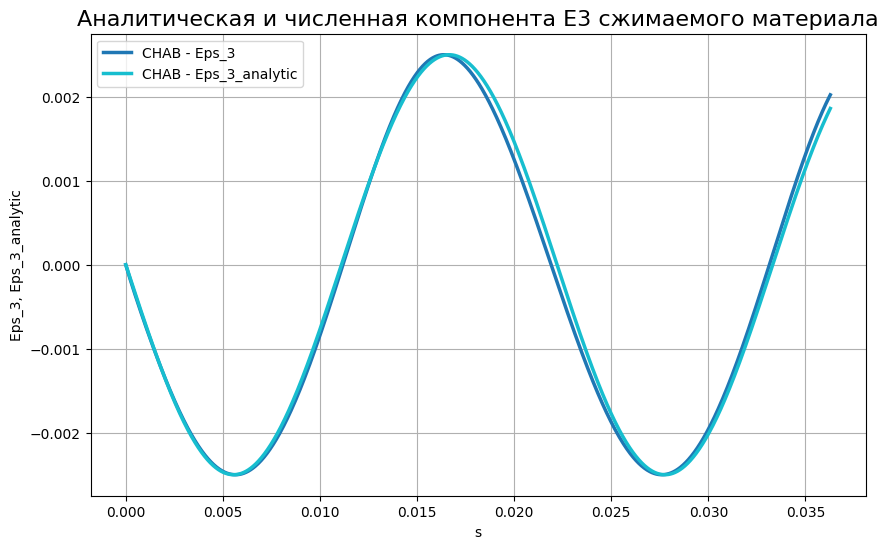

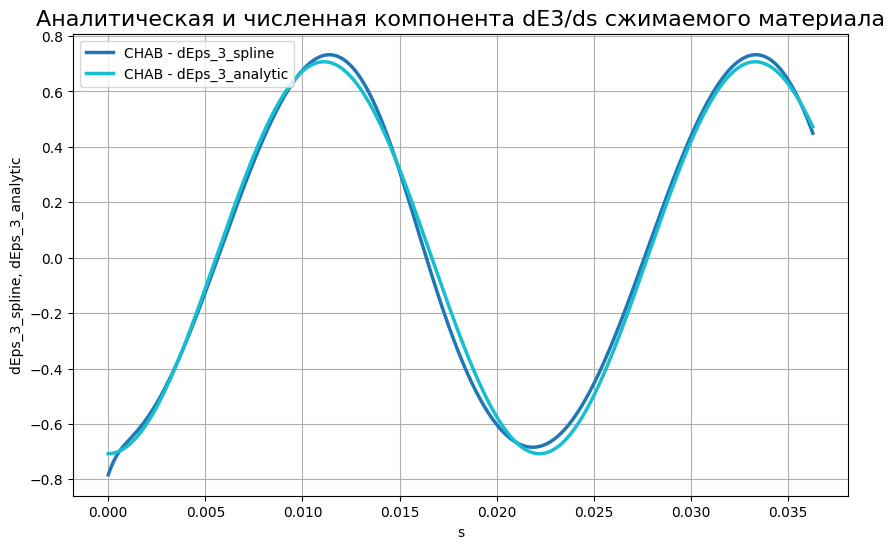

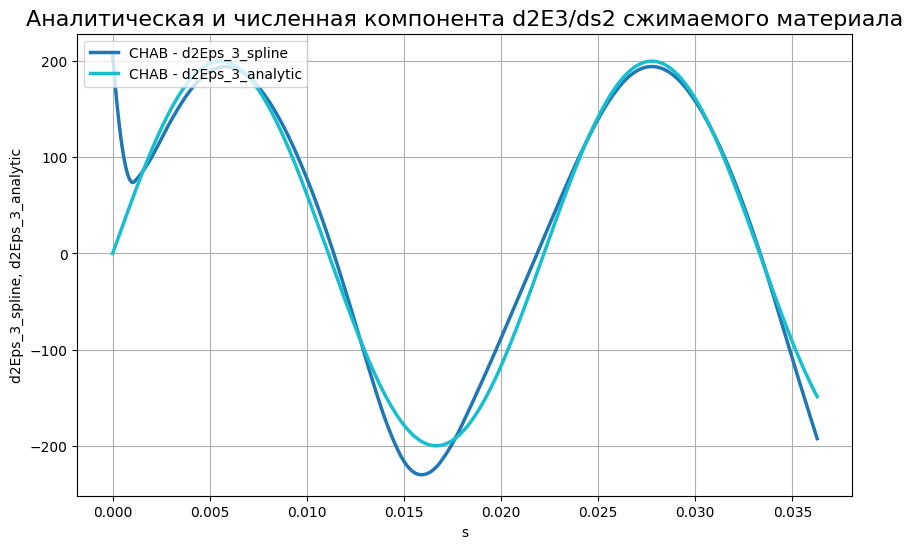

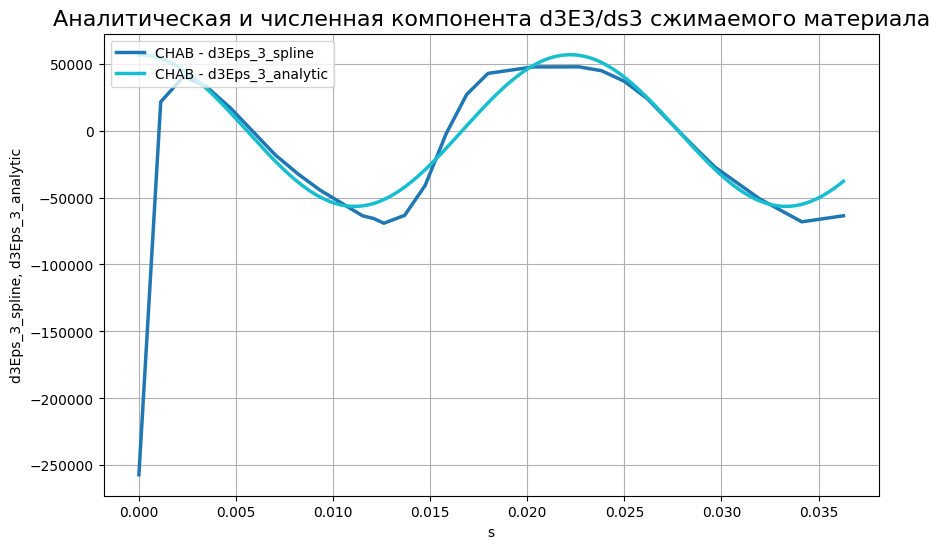

In [21]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["Eps_3",
            "Eps_3_analytic",
        ],
    title="Аналитическая и численная компонента E3 сжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["dEps_3_spline",
            "dEps_3_analytic",
        ],
    title="Аналитическая и численная компонента dE3/ds сжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d2Eps_3_spline",
            "d2Eps_3_analytic",
        ],
    title="Аналитическая и численная компонента d2E3/ds2 сжимаемого материала",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d3Eps_3_spline",
            "d3Eps_3_analytic",
        ],
    title="Аналитическая и численная компонента d3E3/ds3 сжимаемого материала",
    figsize=(10, 6)
)

### 6. Расчет геометрических характеристик траектории

Используя вычисленные производные (скорость ${\bar{\ni'}}$, ускорение ${\bar{\ni''}}$, рывок ${\bar{\ni'''}}$), мы определяем внутреннюю геометрию траектории деформирования в векторном пространстве.

**Вычисляемые параметры:**

1.  **Кривизна $\varkappa$ (Curvature):**
    Характеризует отклонение траектории от прямой линии.
    $$ \varkappa = \frac{|{\bar{\ni'}} \times {\bar{\ni''}}|}{|{\bar{\ni'}}|^3} $$

2.  **Кручение $\tau$ (Torsion):**
    Характеризует выход траектории из плоскости соприкасания (отклонение от плоской кривой).
    $$ \tau = \frac{({\bar{\ni'}} \times {\bar{\ni''}}) \cdot {\bar{\ni'''}}}{|{\bar{\ni'}} \times {\bar{\ni''}}|^2} $$

Расчет производится параллельно для двух наборов данных:
*   **Analytic:** На основе точных формул.
*   **Spline:** На основе численного дифференцирования данных ANSYS.

In [22]:
import numpy as np
from core.calculations import calculate_geometry

for df in (df_stage2, df_stage2_inc):
    s_true, k_true, t_true = calculate_geometry(df, suffix="_analytic", time_col="s")
    df["s_analytic"] = s_true
    df["kappa_analytic"] = k_true
    df["tau_analytic"] = np.round(np.abs(t_true), decimals=7)

    s_spline, k_spline, t_spline = calculate_geometry(df, suffix="_spline", time_col="s")
    df["s_spline"] = s_spline
    df["kappa_spline"] = k_spline
    df["tau_spline"] = np.abs(t_spline)

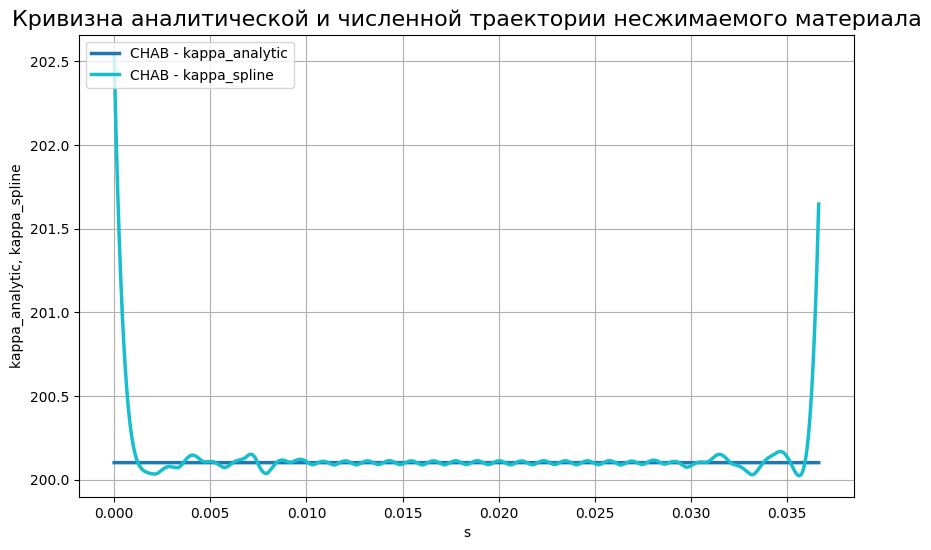

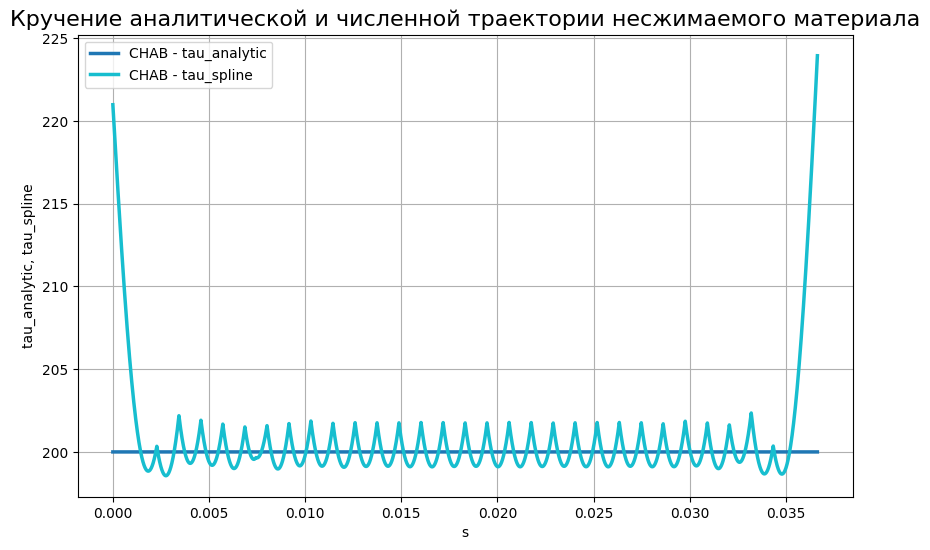

In [23]:
plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["kappa_analytic", "kappa_spline"],
    title="Кривизна аналитической и численной траектории несжимаемого материала",
    figsize=(10, 6)
)

plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["tau_analytic", "tau_spline"],
    title="Кручение аналитической и численной траектории несжимаемого материала",
    figsize=(10, 6)
)

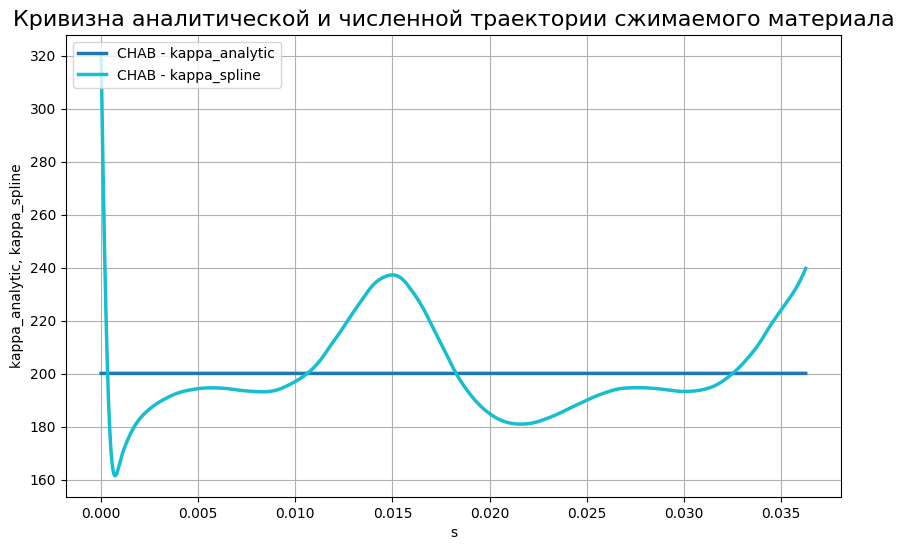

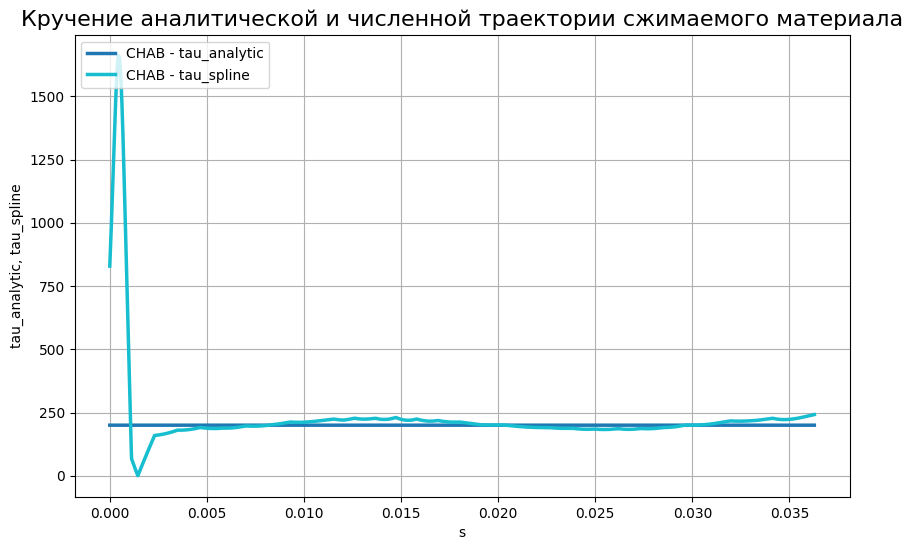

In [24]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["kappa_analytic", "kappa_spline"],
    title="Кривизна аналитической и численной траектории сжимаемого материала",
    figsize=(10, 6)
)

plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["tau_analytic", "tau_spline"],
    title="Кручение аналитической и численной траектории сжимаемого материала",
    figsize=(10, 6)
)

### 7. Векторные свойства материала: Расчет угла сближения

Для анализа векторных свойств материала (отклонения поведения от теории малых упруго-пластических деформаций) необходимо сопоставить направление вектора напряжений $\bar{\sigma}$ с направлением мгновенной скорости деформации ${\bar{\ni'}}$ (касательной к траектории).

**1. Построение вектора напряжений $\bar{\sigma}$**
Вектор напряжений в пространстве Ильюшина строится на основе компонент **девиатора напряжений** $S_{ij}$. Результаты ANSYS (для элемента PLANE182) содержат компоненты тензора напряжений: $\sigma_z$ (осевое), $\sigma_\theta$ (окружное) и $\tau_{z\theta}$ (касательное).

Сначала вычисляются компоненты девиатора:
$$ S_{zz} = \sigma_z - \sigma_{mean}, \quad S_{\theta\theta} = \sigma_\theta - \sigma_{mean}, \quad S_{z\theta} = \tau_{z\theta} $$
где $\sigma_{mean} = \frac{1}{3}(\sigma_z + \sigma_\theta)$.

Компоненты вектора $\bar{\sigma}$ определяются линейным преобразованием:
$$ \sigma_1 = \frac{3}{2} S_{zz} $$
$$ \sigma_2 = \frac{\sqrt{3}}{2} (S_{zz} + 2S_{\theta\theta}) $$
$$ \sigma_3 = \sqrt{3} S_{z\theta} $$

**2. Расчет угла сближения $\vartheta_1$**
Угол сближения (или угол запаздывания) $\vartheta_1$ — это угол между вектором напряжений $\bar{\sigma}$ и вектором скорости деформаций ${\bar{\ni'}}$ в пятимерном пространстве. Он вычисляется через скалярное произведение:

$$ \cos \vartheta_1 = \frac{\bar{\sigma} \cdot {\bar{\ni'}}}{|\bar{\sigma}| \cdot |\dot{{\ni'}}|} $$

Этот параметр характеризует степень неколлинеарности тензоров напряжений и скоростей деформаций, возникающую вследствие сложного нагружения.

In [26]:
df_stress_stage2 = numerical_experiment_chab.loc[
    numerical_experiment_chab["Time"] > split_time,
    ["S_ZZ", "S_TZ", "S_TT", "Time"],
].copy()
df_stress_stage2.reset_index(drop=True, inplace=True)
df_stress_stage2["Time_Local"] = df_stress_stage2["Time"] - split_time

df_stress_stage2[:5]

,S_ZZ,S_TZ,S_TT,Time,Time_Local
0,514.6832,-0.035392,240.4775,100.0100,0.0100
1,514.6855,-0.070782,240.5246,100.0200,0.0200
2,514.6891,-0.123861,240.5954,100.0350,0.0350
3,514.6942,-0.203467,240.7014,100.0575,0.0575
4,514.7016,-0.322848,240.8604,100.0913,0.0913


In [27]:
df_stress_stage2_inc = numerical_experiment_chab_inc.loc[
    numerical_experiment_chab_inc["Time"] > split_time,
    ["S_ZZ", "S_TZ", "S_TT", "Time"],
].copy()
df_stress_stage2_inc.reset_index(drop=True, inplace=True)
df_stress_stage2_inc["Time_Local"] = df_stress_stage2_inc["Time"] - split_time

df_stress_stage2_inc[:5]

,S_ZZ,S_TZ,S_TT,Time,Time_Local
0,522.8975,-0.030672,261.4949,100.0100,0.0100
1,522.8992,-0.061340,261.5419,100.0200,0.0200
2,522.9018,-0.107335,261.6123,100.0350,0.0350
3,522.9055,-0.176310,261.7179,100.0575,0.0575
4,522.9108,-0.279732,261.8760,100.0913,0.0913


### Угол сближения $\Theta$ между напряжением и «скоростью» деформаций

**Вектор напряжений** $(\mathrm{Sig}_1, \mathrm{Sig}_2, \mathrm{Sig}_3)$ в пространстве Ильюшина строится из компонент тензора напряжений **результата расчёта в ANSYS** (осевое $S_{ZZ}$, окружное $S_{TT}$, касательное $S_{TZ}$).

**Вектор скорости деформаций** (вдоль траектории по параметру длины дуги $s$) задаётся по-разному:

- **Аналитический случай** — производные $(\mathrm{d}\varepsilon_1/\mathrm{d}s,\, \mathrm{d}\varepsilon_2/\mathrm{d}s,\, \mathrm{d}\varepsilon_3/\mathrm{d}s)$ берутся **из замкнутых аналитических формул** винтовой траектории для несжимаемого материала.

- **Численный случай** — те же производные по $s$ получаются **из сглаживающего сплайна** по дискретным точкам численной траектории.

Угол сближения $\Theta$ в каждой точке — угол между вектором напряжений (ANSYS) и соответствующим вектором скорости деформаций (**аналитика** или **сплайн**).

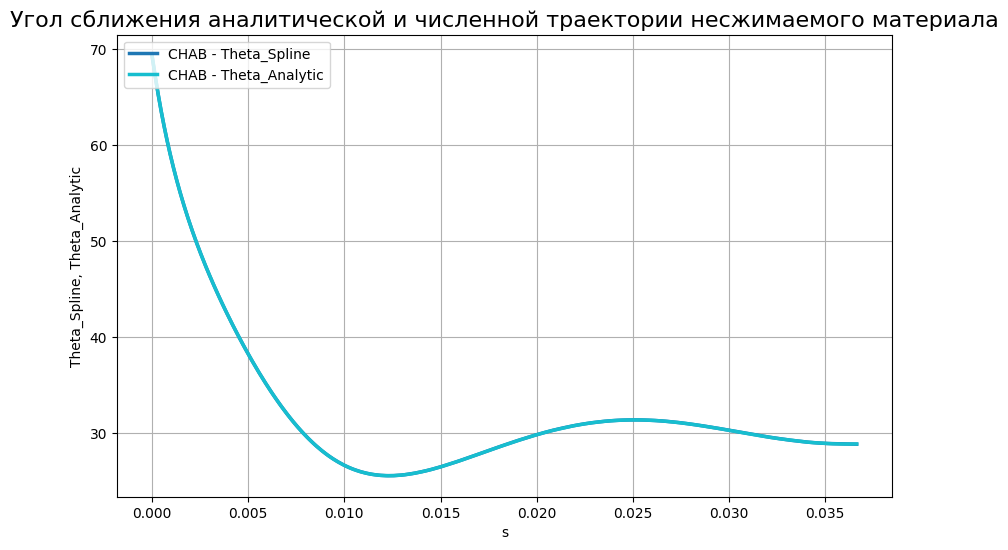

In [28]:
from core.calculations import calculate_stress_vector, calculate_theta

sig_1i, sig_2i, sig_3i = calculate_stress_vector(df_stress_stage2_inc)
df_stage2_inc["Sig_1"] = sig_1i.to_numpy()
df_stage2_inc["Sig_2"] = sig_2i.to_numpy()
df_stage2_inc["Sig_3"] = sig_3i.to_numpy()

df_stage2_inc["Theta_Spline"] = calculate_theta(df_stage2_inc, deriv_suffix="_spline")
df_stage2_inc["Theta_Analytic"] = calculate_theta(df_stage2_inc, deriv_suffix="_analytic")

plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["Theta_Spline", "Theta_Analytic"],
    title="Угол сближения аналитической и численной траектории несжимаемого материала",
    figsize=(10, 6)
)

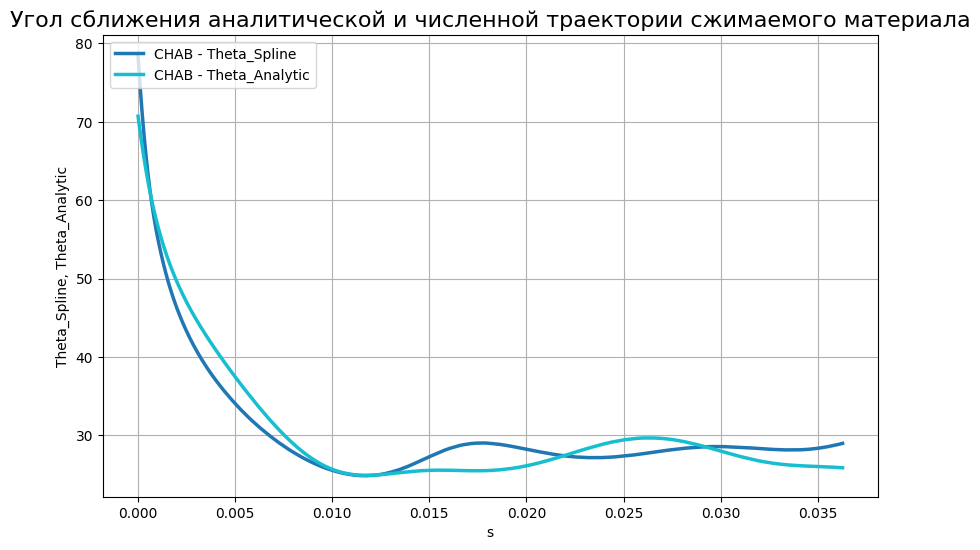

In [29]:
from core.calculations import calculate_stress_vector, calculate_theta

sig_1, sig_2, sig_3 = calculate_stress_vector(df_stress_stage2)
df_stage2["Sig_1"] = sig_1.to_numpy()
df_stage2["Sig_2"] = sig_2.to_numpy()
df_stage2["Sig_3"] = sig_3.to_numpy()

df_stage2["Theta_Spline"] = calculate_theta(df_stage2, deriv_suffix="_spline")
df_stage2["Theta_Analytic"] = calculate_theta(df_stage2, deriv_suffix="_analytic")

plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["Theta_Spline", "Theta_Analytic"],
    title="Угол сближения аналитической и численной траектории сжимаемого материала",
    figsize=(10, 6)
)

### 8. Аппроксимация среднего напряжения

Анализ результатов показал, что прямое численное дифференцирование экспериментальных данных (даже с использованием сглаживающих сплайнов) не позволяет получить устойчивые значения высших производных, необходимых для расчета кручения. Сплайны чувствительны к локальному шуму и демонстрируют краевые эффекты.

Учитывая физическую природу процесса (движение по винтовой траектории), изменение объема (и пропорционального ему среднего напряжения) должно носить периодический характер с наложением монотонного тренда. Вместо локального сглаживания мы применяем **глобальную аппроксимацию** зависимости среднего напряжения $\sigma_{mean}$ от длины дуги $s$.

**Модель аппроксимации:**

Зависимость описывается гармонической функцией с линейным трендом:

$$ \sigma_{mean}(s) \approx p \cdot \cos(\omega \cdot s + \phi) + b_1 \cdot s + b_2 $$

где параметры модели имеют следующий физический смысл:
*   $p$ — **Амплитуда** пульсаций среднего напряжения (вызвана вращением вектора деформаций).
*   $\omega$ — **Пространственная частота** колебаний (связана с геометрией винтовой линии).
*   $\phi$ — **Фазовый сдвиг**.
*   $b_1$ — **Линейный тренд** (накопление гидростатического давления/изменения объема в процессе пластического деформирования).
*   $b_2$ — **Базовое смещение**.

Найденная аналитическая зависимость позволяет вычислить гладкие производные любого порядка для коррекции вектора Ильюшина.

Параметры аппроксимации среднего напряжения (несжимаемый материал):
  Амплитуда (p):       74.3059 МПа
  Пространств. частота (w): 284.9573 рад/мм
  Линейный тренд (b1): 645.4417 МПа/мм
  Смещение (phi): 0.7682 рад
  Базовое смещение (b2): 233.5997 МПа


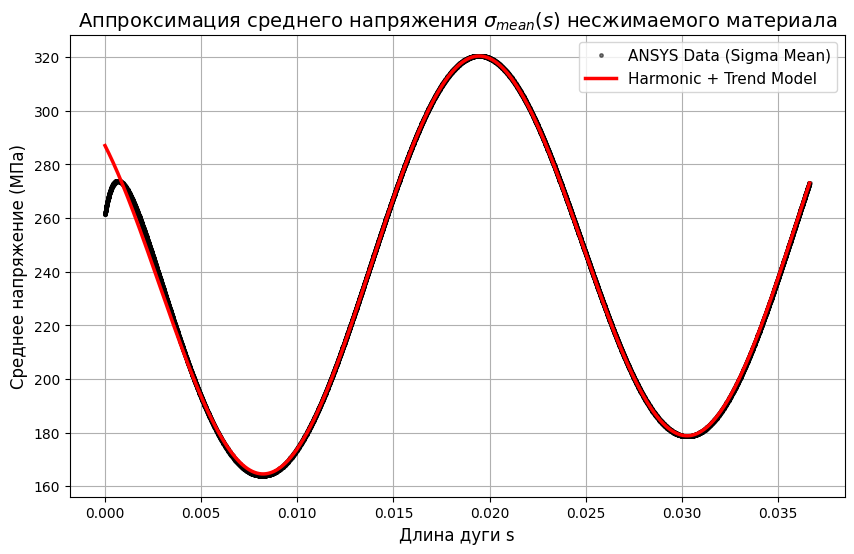

In [31]:
from core.derivatives.stress_approximation import VolumetricModel
import pandas as pd
import matplotlib.pyplot as plt

cols_stress = ['S_ZZ', 'S_TT', 'S_RR']
df_stress_inc = numerical_experiment_chab_inc.loc[numerical_experiment_chab_inc['Time'] > split_time, cols_stress].reset_index(drop=True)
df_stage2_inc = pd.concat([df_stage2_inc, df_stress_inc], axis=1)
df_stage2_inc['Sigma_Mean'] = (df_stage2_inc['S_ZZ'] + df_stage2_inc['S_TT'] + df_stage2_inc['S_RR']) / 3.0

vol_model_inc = VolumetricModel()
vol_model_inc.fit(df_stage2_inc['s'].values, df_stage2_inc['Sigma_Mean'].values)


s_vals = df_stage2_inc['s'].values
sigma_real = df_stage2_inc['Sigma_Mean'].values
sigma_approx = vol_model_inc.predict(s_vals)

p, w, phi, b1, b2 = vol_model_inc.params

print(f"Параметры аппроксимации среднего напряжения (несжимаемый материал):")
print(f"  Амплитуда (p):       {p:.4f} МПа")
print(f"  Пространств. частота (w): {w:.4f} рад/мм")
print(f"  Линейный тренд (b1): {b1:.4f} МПа/мм")
print(f"  Смещение (phi): {phi:.4f} рад")
print(f"  Базовое смещение (b2): {b2:.4f} МПа")

plt.figure(figsize=(10, 6))
plt.plot(s_vals, sigma_real, 'k.', markersize=5, alpha=0.5, label='ANSYS Data (Sigma Mean)')
plt.plot(s_vals, sigma_approx, 'r-', linewidth=2.5, label='Harmonic + Trend Model')

plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(s)$ несжимаемого материала', fontsize=14)
plt.xlabel('Длина дуги s', fontsize=12)
plt.ylabel('Среднее напряжение (МПа)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

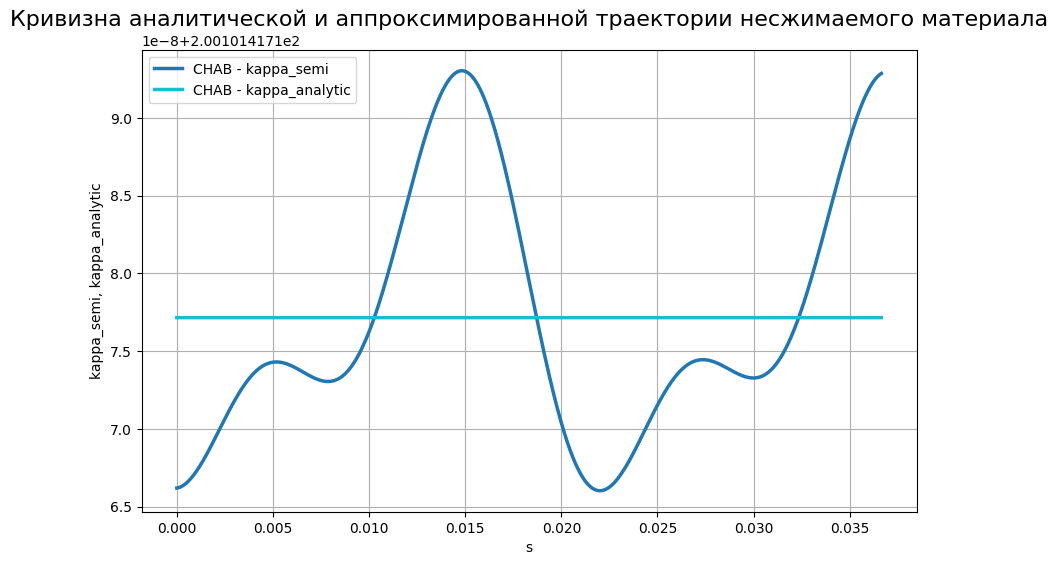

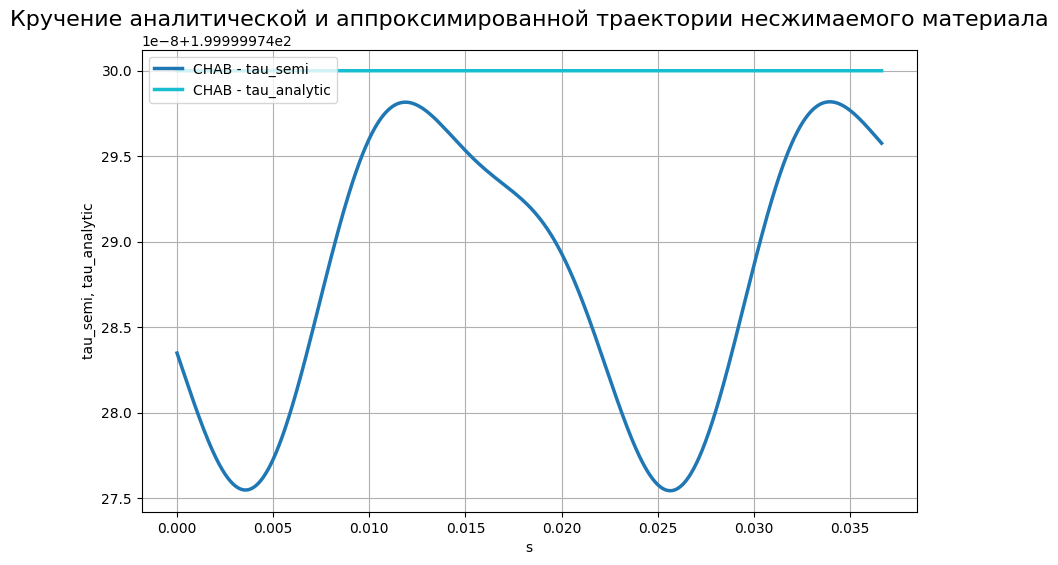

In [32]:
from core.derivatives.stress_approximation import GeometricProperties

df = df_stage2_inc.copy()
x = df["s"].to_numpy(dtype=float)   


geom = GeometricProperties(vol_model_inc, E=2.05e5, nu=0.4999999999)
kappa, tau = geom.compute_geometry(df_stage2_inc, x)

df_stage2_inc['kappa_semi'] = kappa
df_stage2_inc['tau_semi'] = np.abs(tau)

plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["kappa_semi", "kappa_analytic"],
    title="Кривизна аналитической и аппроксимированной траектории несжимаемого материала",
    figsize=(10, 6)
)

plot_xy(
    data_pairs=[(model_name, df_stage2_inc)],
    x_col="s",
    y_cols=["tau_semi", "tau_analytic"],
    title="Кручение аналитической и аппроксимированной траектории несжимаемого материала",
    figsize=(10, 6)
)

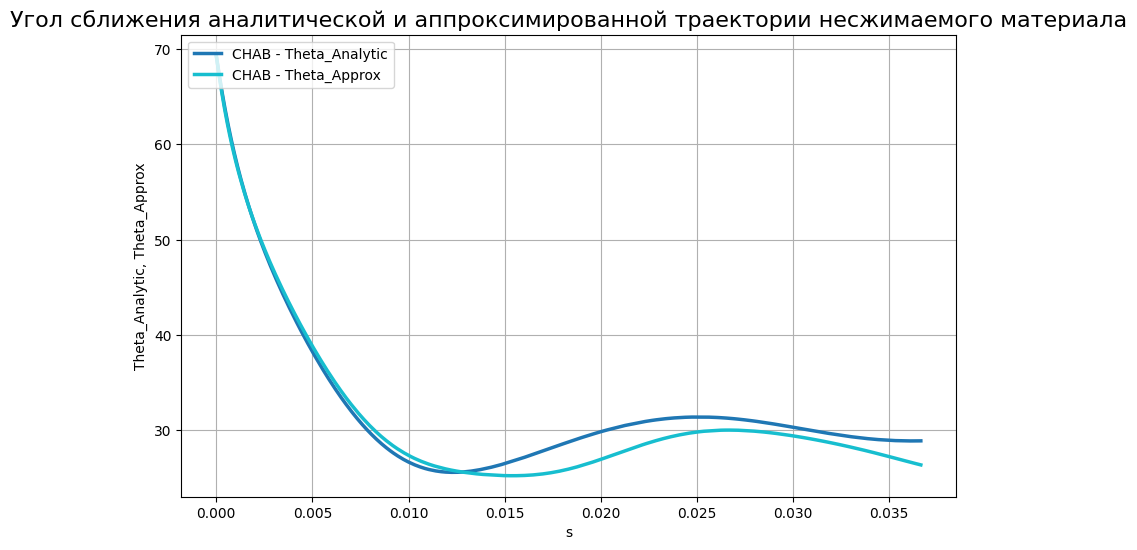

In [33]:
v1, v2, v3 = geom.get_derivatives(df_stage2, x)

df_stage2_inc['dEps_1_approx'] = v1
df_stage2_inc['dEps_2_approx'] = v2
df_stage2_inc['dEps_3_approx'] = v3

theta_semi = calculate_theta(df_stage2_inc, deriv_suffix='_approx')
df_stage2_inc['Theta_Approx'] = theta_semi

plot_xy(
    [(model_name, df_stage2_inc)],
    "s",
    ['Theta_Analytic', 'Theta_Approx'],
    title="Угол сближения аналитической и аппроксимированной траектории несжимаемого материала",
    figsize=(10, 6)
)

Параметры аппроксимации среднего напряжения (сжимаемый материал):
  Амплитуда (p):       71.5671 МПа
  Пространств. частота (w): 285.3407 рад/мм
  Линейный тренд (b1): 794.6677 МПа/мм
  Смещение (phi): 0.7578 рад
  Базовое смещение (b2): 226.2756 МПа


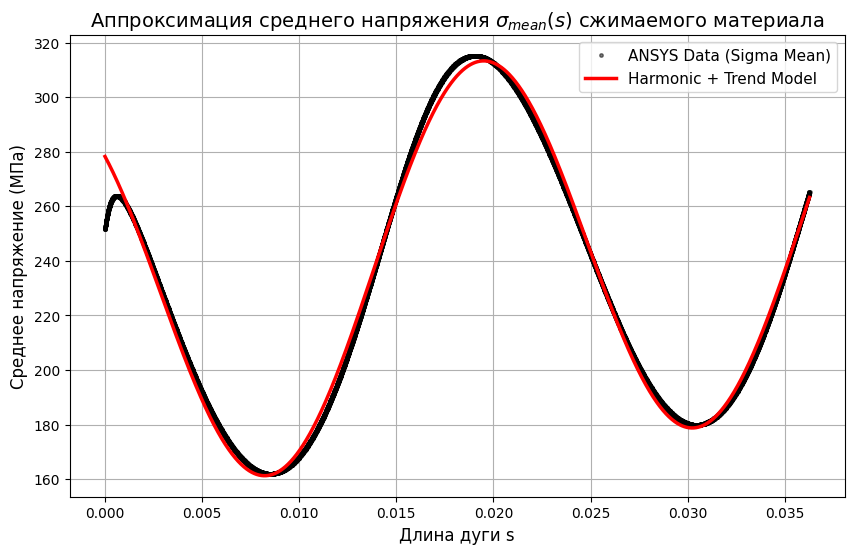

In [34]:
from core.derivatives.stress_approximation import VolumetricModel
import pandas as pd
import matplotlib.pyplot as plt

cols_stress = ['S_ZZ', 'S_TT', 'S_RR']
df_stress = numerical_experiment_chab.loc[numerical_experiment_chab['Time'] > split_time, cols_stress].reset_index(drop=True)
df_stage2 = pd.concat([df_stage2, df_stress], axis=1)
df_stage2['Sigma_Mean'] = (df_stage2['S_ZZ'] + df_stage2['S_TT'] + df_stage2['S_RR']) / 3.0

vol_model = VolumetricModel()
vol_model.fit(df_stage2['s'].values, df_stage2['Sigma_Mean'].values)


s_vals = df_stage2['s'].values
sigma_real = df_stage2['Sigma_Mean'].values
sigma_approx = vol_model.predict(s_vals)

p, w, phi, b1, b2 = vol_model.params

print(f"Параметры аппроксимации среднего напряжения (сжимаемый материал):")
print(f"  Амплитуда (p):       {p:.4f} МПа")
print(f"  Пространств. частота (w): {w:.4f} рад/мм")
print(f"  Линейный тренд (b1): {b1:.4f} МПа/мм")
print(f"  Смещение (phi): {phi:.4f} рад")
print(f"  Базовое смещение (b2): {b2:.4f} МПа")

plt.figure(figsize=(10, 6))
plt.plot(s_vals, sigma_real, 'k.', markersize=5, alpha=0.5, label='ANSYS Data (Sigma Mean)')
plt.plot(s_vals, sigma_approx, 'r-', linewidth=2.5, label='Harmonic + Trend Model')

plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(s)$ сжимаемого материала', fontsize=14)
plt.xlabel('Длина дуги s', fontsize=12)
plt.ylabel('Среднее напряжение (МПа)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

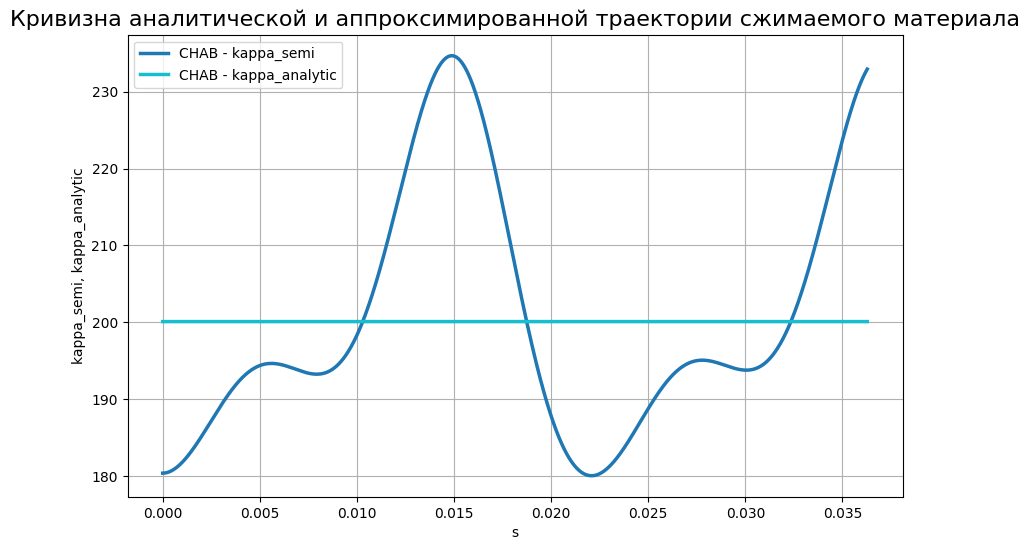

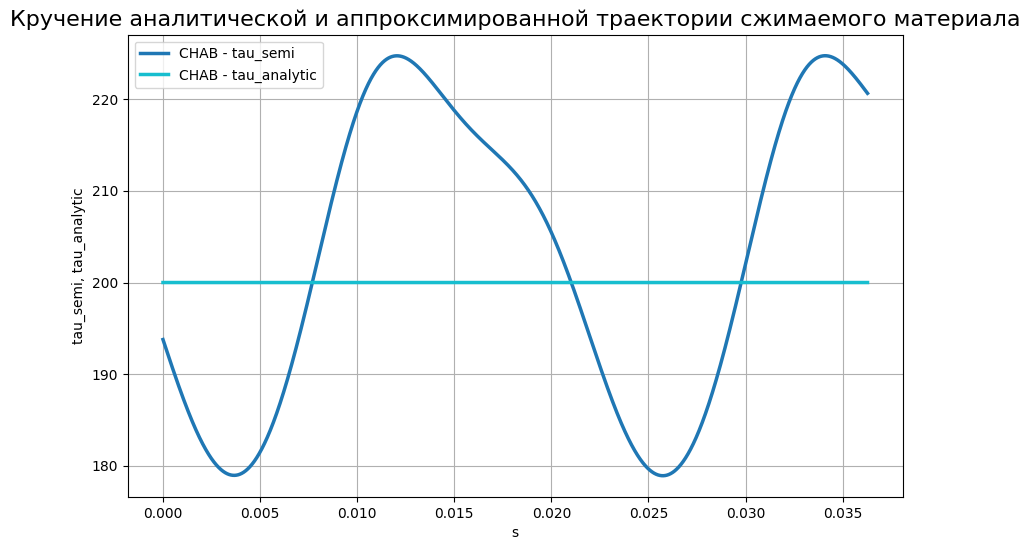

In [40]:
from core.derivatives.stress_approximation import GeometricProperties

df = df_stage2.copy()
x = df["s"].to_numpy(dtype=float)   


geom = GeometricProperties(vol_model, E=2.05e5, nu=0.2999999999)
kappa, tau = geom.compute_geometry(df_stage2, x)

df_stage2['kappa_semi'] = kappa
df_stage2['tau_semi'] = np.abs(tau)

plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["kappa_semi", "kappa_analytic"],
    title="Кривизна аналитической и аппроксимированной траектории сжимаемого материала",
    figsize=(10, 6)
)

plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["tau_semi", "tau_analytic"],
    title="Кручение аналитической и аппроксимированной траектории сжимаемого материала",
    figsize=(10, 6)
)

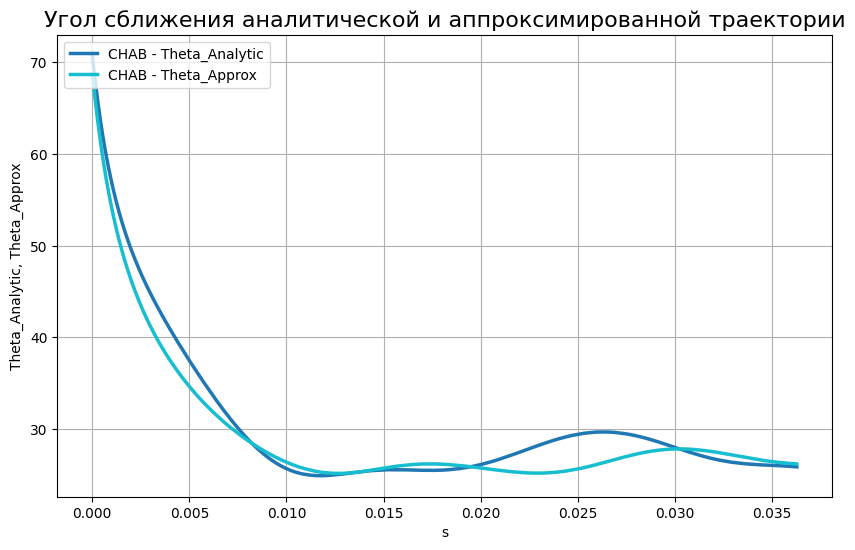

In [41]:
v1, v2, v3 = geom.get_derivatives(df_stage2, x)

df_stage2['dEps_1_approx'] = v1
df_stage2['dEps_2_approx'] = v2
df_stage2['dEps_3_approx'] = v3

theta_semi = calculate_theta(df_stage2, deriv_suffix='_approx')
df_stage2['Theta_Approx'] = theta_semi

plot_xy(
    [(model_name, df_stage2)],
    "s",
    ['Theta_Analytic', 'Theta_Approx'],
    title="Угол сближения аналитической и аппроксимированной траектории",
    figsize=(10, 6)
)

### 9. Сопоставление с экспериментальными данными

Для верификации численной модели используются данные эксперимента 1986 года. При обработке экспериментальных данных приняты следующие допущения и правила расчёта.

1. **Условие несжимаемости.** В оригинальном эксперименте деформирование рассматривалось в предположении идеальной несжимаемости материала ($\nu = 0{,}5$). Радиальная деформация $\varepsilon_{rr}$ не измерялась; средняя деформация принимается равной нулю ($\varepsilon_{\mathrm{mean}} = 0$).

2. **Длина дуги $s$ в пространстве Ильюшина.** Эксперимент — дискретный набор точек $(N_1,N_2,N_3)_k$. Между соседними замерами задаётся приращение $\Delta \mathbf{N}_k = \mathbf{N}_k - \mathbf{N}_{k-1}$, длина шага $\Delta s_k = \|\Delta \mathbf{N}_k\|$, накопленная дуга
   $$s_n = \sum_{k=1}^{n} \Delta s_k, \quad s_0 = 0.$$
   Аналогично измеряем длину дуги для численных данных.

3. **Касательная к траектории деформаций (вектор скорости по дуге).** Направление движения по траектории в точке $k$ связывается с приращениями между соседними точками: малый вектор $\Delta \mathbf{N}_k$ лежит вдоль хорды; при мелкой дискретизации касательная к полилинии совпадает с пределом $\Delta \mathbf{N}_k / \Delta s_k$. В реализации для угла сближения компоненты производных $\mathrm d N_i / \mathrm d s$ оцениваются численно по уже посчитанной дуге $s$. Эти три производные играют роль вектора скорости деформаций в пространстве Ильюшина **вдоль экспериментальной дуги**.

In [38]:
import numpy as np
import pandas as pd

from core.reader import load_experimental_data
from core.calculations import (
    calculate_ilushin_strain_vector,
    calculate_stress_vector,
    calculate_theta,
    ilushin_strain_path_length,
)

exp_folder = "../experimental_vint"
split_time_exp = 14.0

raw = load_experimental_data(exp_folder)
raw["S_TZ"] = -raw["S_TZ"]
raw["EPTO_TZ"] = -raw["EPTO_TZ"]

illyu = calculate_ilushin_strain_vector(raw, compressible=False)

df_exp_vint = raw.loc[raw["Time"] >= split_time_exp].copy()
df_exp_vint = df_exp_vint.merge(
    illyu.loc[illyu["Time"] >= split_time_exp, ["Time", "Eps_1", "Eps_2", "Eps_3"]],
    on="Time",
    how="left",
).reset_index(drop=True)

df_exp_vint = df_exp_vint.merge(
    ilushin_strain_path_length(
        df_exp_vint,
        time_col="Time",
        use_existing_ilushin_strains=True,
    )[["Time", "s"]],
    on="Time",
    how="left",
)

s1, s2, s3 = calculate_stress_vector(df_exp_vint)
df_exp_vint["Sig_1_exp"] = np.asarray(s1, dtype=float)
df_exp_vint["Sig_2_exp"] = np.asarray(s2, dtype=float)
df_exp_vint["Sig_3_exp"] = np.asarray(s3, dtype=float)
df_exp_vint["S_EQV_exp"] = np.sqrt(
    df_exp_vint["Sig_1_exp"] ** 2
    + df_exp_vint["Sig_2_exp"] ** 2
    + df_exp_vint["Sig_3_exp"] ** 2
)

s_arr = df_exp_vint["s"].to_numpy(dtype=float)
for k in (1, 2, 3):
    df_exp_vint[f"dEps_{k}_exp"] = np.gradient(
        df_exp_vint[f"Eps_{k}"].to_numpy(dtype=float),
        s_arr,
    )

df_exp_vint["Theta_exp"] = calculate_theta(
    pd.DataFrame(
        {
            "Sig_1": df_exp_vint["Sig_1_exp"],
            "Sig_2": df_exp_vint["Sig_2_exp"],
            "Sig_3": df_exp_vint["Sig_3_exp"],
            "dEps_1_exp": df_exp_vint["dEps_1_exp"],
            "dEps_2_exp": df_exp_vint["dEps_2_exp"],
            "dEps_3_exp": df_exp_vint["dEps_3_exp"],
        }
    ),
    deriv_suffix="_exp",
)

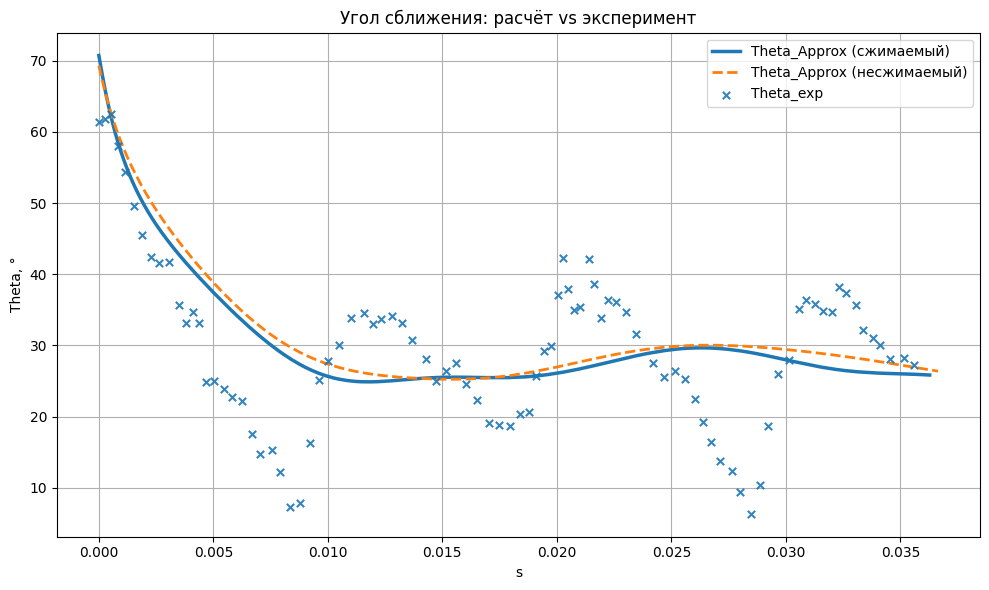

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df_stage2["s"],
    df_stage2["Theta_Approx"],
    "-",
    label="Theta_Approx (сжимаемый)",
    lw=2.5,
)
ax.plot(
    df_stage2_inc["s"],
    df_stage2_inc["Theta_Approx"],
    "--",
    label="Theta_Approx (несжимаемый)",
    lw=2.0,
)
ax.scatter(
    df_exp_vint["s"],
    df_exp_vint["Theta_exp"],
    marker="x",
    s=28,
    alpha=0.9,
    label="Theta_exp",
    zorder=5,
)

ax.set_xlabel("s")
ax.set_ylabel("Theta, °")
ax.set_title("Угол сближения: расчёт vs эксперимент")
ax.grid(True)
ax.legend(loc="best")
plt.tight_layout()
plt.show()